# Importing data

In [85]:
!pip install gdown --quiet

Here we are importing only group 1 data for which the corresponding gid number will be taken

In [86]:
import gdown
import pandas as pd
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

file_id = "1f0v-bwSuFMkpSqLUFgInvru3VgT_DM_T"
gid = "1863419818" # ONLY EXPORTING GROUP 1 DATA

export_url = f"https://docs.google.com/spreadsheets/d/{file_id}/export?format=xlsx&gid={gid}"

output_file = "GR1_data.xlsx"
gdown.download(export_url, output_file, quiet=True, fuzzy=True)
df = pd.read_excel(output_file,header=1)
# Removing columns after year 10.4
idx = df.columns.get_loc('Year 10.4')
df = df.iloc[:, :idx + 1]
print(f"Kept columns up to 'Year 10.4' (index {idx})")


print("\nPreview of cleaned data (first 5 rows):")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.set_index('Borrower Number', inplace=True)
display(df.head())

Kept columns up to 'Year 10.4' (index 50)

Preview of cleaned data (first 5 rows):
Shape: 2000 rows × 51 columns


,Year 1,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10,...,Year 1.4,Year 2.4,Year 3.4,Year 4.4,Year 5.4,Year 6.4,Year 7.4,Year 8.4,Year 9.4,Year 10.4
Borrower Number,,,,,,,,,,,,,,,,,,,,,
1,7,5,1,4,1,1,3,4,4,7,...,1.454501,1.674278,1.193080,1.208287,1.132344,1.232171,1.625900,1.756417,1.516587,1.926830
2,7,5,5,4,5,8,3,7,6,2,...,1.979697,1.224056,1.438737,1.592659,1.703376,1.516897,1.637495,1.758756,1.507760,1.328800
3,6,5,6,8,3,6,3,6,7,7,...,1.191992,1.103035,1.980766,1.956139,1.440590,1.519596,1.259628,1.836737,1.543743,1.781203
4,2,1,7,1,1,6,5,1,4,8,...,1.665324,1.464344,1.632384,1.316200,1.097683,1.746302,1.088347,1.298740,1.910121,1.667142
5,4,5,7,5,1,7,3,2,2,6,...,1.099634,1.047584,1.958802,1.059876,1.065049,1.107836,1.338825,1.713397,1.636895,1.321673


Creating dataframes for each
1.   Rating,
2.   Amount in crores,
3.   Loss Given Default and
4.   Exposure at Default




  

In [87]:
rating_cols = [col for col in df.columns if col.endswith('.1')]
amount_cols = [col for col in df.columns if col.endswith('.2')]
lgd_cols = [col for col in df.columns if col.endswith('.3')]
ead_cols = [col for col in df.columns if col.endswith('.4')]

ratings_df = df[rating_cols].copy()
amount_df = df[amount_cols].copy()
lgd_df = df[lgd_cols].copy()
ead_df = df[ead_cols].copy()

ratings_df.columns = [col.replace('.1', '') for col in ratings_df.columns]
amount_df.columns = [col.replace('.2', '') for col in amount_df.columns]
lgd_df.columns = [col.replace('.3', '') for col in lgd_df.columns]
ead_df.columns = [col.replace('.4', '') for col in ead_df.columns]


print("Ratings DataFrame:")
display(ratings_df.head())

print("Amount DataFrame:")
display(amount_df.head())

print("LGD DataFrame:")
display(lgd_df.head())

print("EAD DataFrame:")
display(ead_df.head())


Ratings DataFrame:


,Year 1,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10
Borrower Number,,,,,,,,,,
1,C,BB,AAA,BBB,AAA,AAA,A,BBB,BBB,C
2,C,BB,BB,BBB,BB,D,A,C,B,AA
3,B,BB,B,D,A,B,A,B,C,C
4,AA,AAA,C,AAA,AAA,B,BB,AAA,BBB,D
5,BBB,BB,C,BB,AAA,C,A,AA,AA,B


Amount DataFrame:


,Year 1,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10
Borrower Number,,,,,,,,,,
1,7.635529,18.985657,13.515099,6.006280,2.145868,3.885953,4.764926,25.575546,22.129175,9.820143
2,5.139407,1.321785,11.328470,4.499839,2.681232,7.879706,6.256955,5.545800,29.072697,25.372435
3,8.143038,19.816412,3.791239,18.411536,11.233816,10.311028,23.494759,8.533503,9.620172,2.103718
4,9.180573,8.204443,17.529242,1.345844,14.151721,27.177839,4.227878,22.474171,6.545246,7.815481
5,3.071967,1.451086,5.995648,5.416071,25.105471,21.063454,4.120435,25.158716,17.632724,12.691181


LGD DataFrame:


,Year 1,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10
Borrower Number,,,,,,,,,,
1,0.894359,0.101861,0.253904,0.153502,0.538554,0.109141,0.712254,0.109851,0.626800,0.476225
2,0.152873,0.285452,0.507654,0.561612,0.780721,0.492481,0.146741,0.111854,0.607191,0.712672
3,0.875298,0.896685,0.630946,0.345455,0.274412,0.103338,0.105289,0.136805,0.323327,0.545431
4,0.744784,0.469324,0.778316,0.544558,0.801676,0.511351,0.259510,0.308168,0.820393,0.675928
5,0.601070,0.278070,0.459743,0.878095,0.361721,0.844432,0.318447,0.588978,0.677592,0.434888


EAD DataFrame:


,Year 1,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10
Borrower Number,,,,,,,,,,
1,1.454501,1.674278,1.193080,1.208287,1.132344,1.232171,1.625900,1.756417,1.516587,1.926830
2,1.979697,1.224056,1.438737,1.592659,1.703376,1.516897,1.637495,1.758756,1.507760,1.328800
3,1.191992,1.103035,1.980766,1.956139,1.440590,1.519596,1.259628,1.836737,1.543743,1.781203
4,1.665324,1.464344,1.632384,1.316200,1.097683,1.746302,1.088347,1.298740,1.910121,1.667142
5,1.099634,1.047584,1.958802,1.059876,1.065049,1.107836,1.338825,1.713397,1.636895,1.321673


# 1. Exploratory Data Analysis


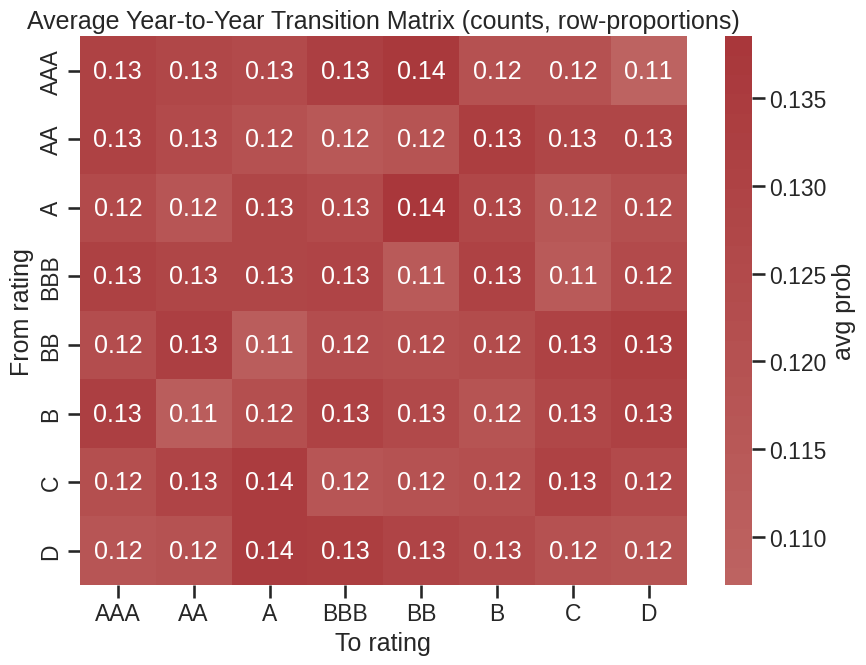

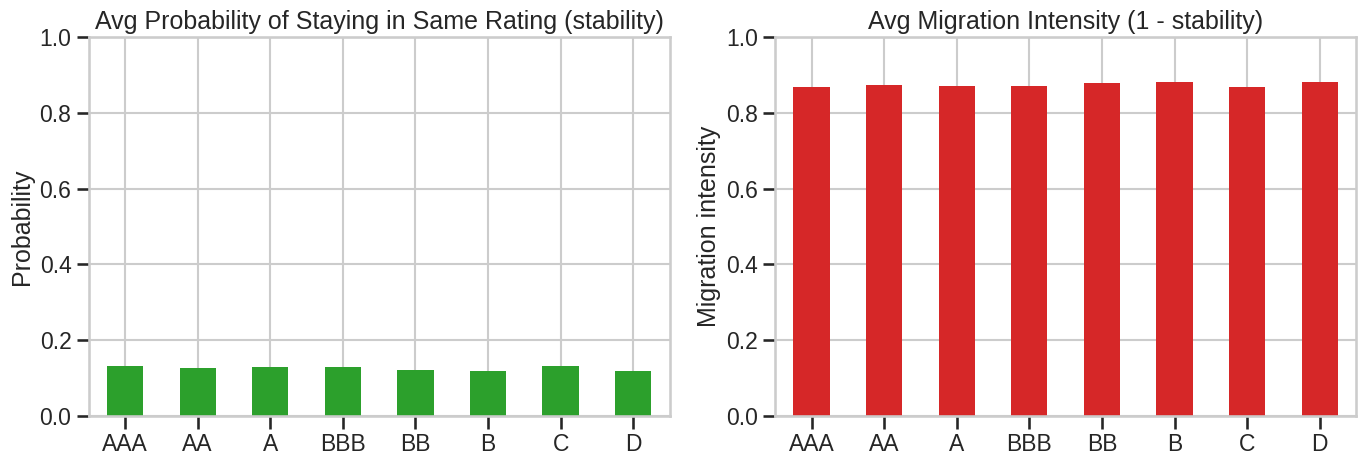

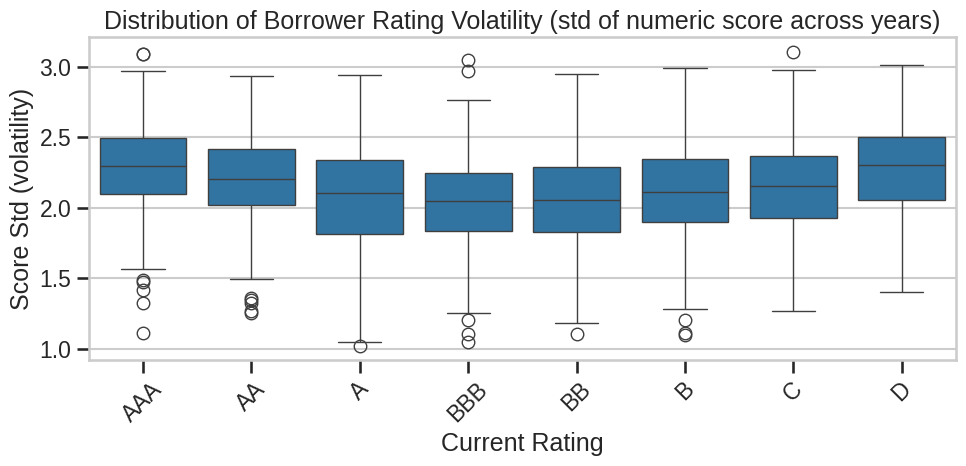

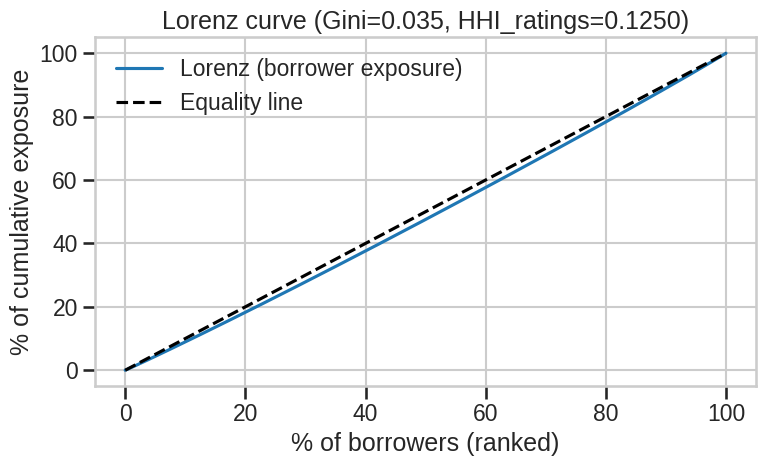

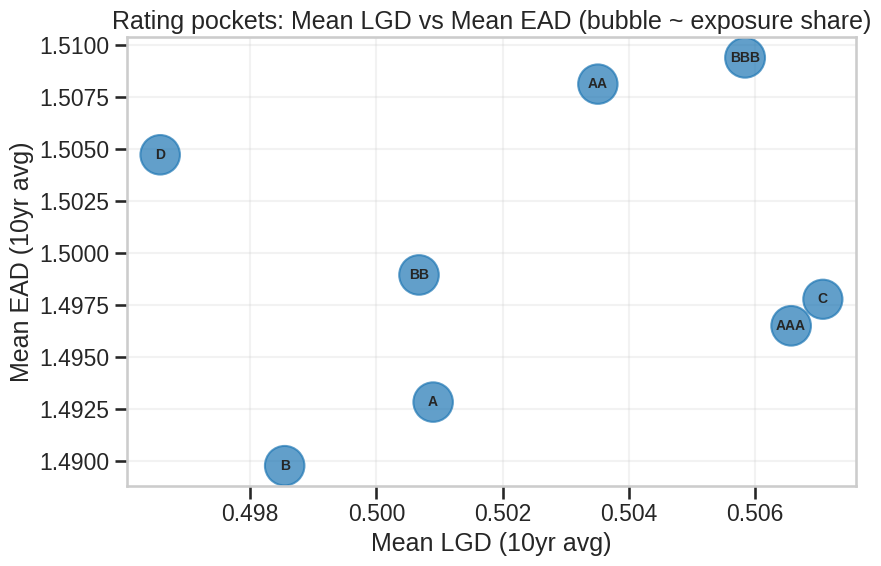

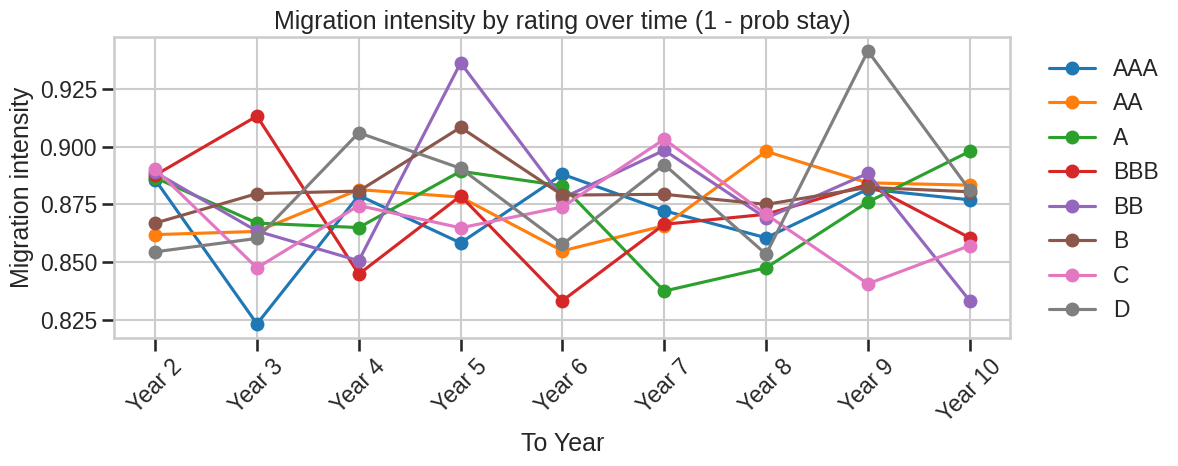

,stability,migration_intensity,total_ead,exposure_share_pct,mean_lgd,median_borrower_vol
rating,,,,,,
AAA,0.130475,0.869525,3772.651549,12.577661,0.506576,2.295644
AA,0.125430,0.874570,3726.577813,12.424055,0.503512,2.202272
A,0.127790,0.872210,3740.999674,12.472137,0.500900,2.107131
BBB,0.128998,0.871002,3820.281027,12.736453,0.505846,2.050609
BB,0.121532,0.878468,3763.834084,12.548264,0.500676,2.051828
B,0.118674,0.881326,3745.244623,12.486289,0.498546,2.109502
C,0.130792,0.869208,3680.013859,12.268816,0.507079,2.155226
D,0.118066,0.881934,3745.255472,12.486325,0.496572,2.300000



Key metrics: borrowers=2000, HHI_ratings=0.1250, Gini_borrower_exposure=0.035


In [88]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("talk")

rating_order = ["AAA","AA","A","BBB","BB","B","C","D"]
years = ratings_df.columns.tolist()

score_map = {r:i+1 for i,r in enumerate(rating_order)}

rows = []
for y in years:
    rcol = ratings_df[y]
    ead_col = ead_df[y] if y in ead_df.columns else amount_df[y]
    lgd_col = lgd_df[y] if y in lgd_df.columns else pd.Series(np.nan, index=ratings_df.index)
    for borrower in ratings_df.index:
        r = rcol.get(borrower, np.nan)
        if pd.isna(r):
            continue
        rows.append({
            "borrower": borrower,
            "year": y,
            "rating": str(r).strip().upper(),
            "ead": float(ead_col.loc[borrower]) if borrower in ead_col.index else 0.0,
            "lgd": float(lgd_col.loc[borrower]) if borrower in lgd_col.index and not pd.isna(lgd_col.loc[borrower]) else np.nan
        })
long = pd.DataFrame(rows)
long = long[long['rating'].isin(rating_order)].copy()
long['score'] = long['rating'].map(score_map)

#Year-to-year transition matrices(counts and exposure-weighted)
def transition_matrix(from_year, to_year, by_exposure=False):
    df_f = ratings_df[from_year].rename('from')
    df_t = ratings_df[to_year].rename('to')
    merged = pd.concat([df_f, df_t], axis=1).dropna()
    merged.columns = ['from','to']
    if by_exposure:
        w = ( (ead_df[from_year] if from_year in ead_df else amount_df[from_year])
            + (ead_df[to_year] if to_year in ead_df else amount_df[to_year]) ) / 2
        merged = merged.join(w.rename('weight'))
        tab = merged.pivot_table(index='from', columns='to', values='weight', aggfunc='sum')
        tab = tab.reindex(index=rating_order, columns=rating_order).fillna(0)
        tab = tab.div(tab.sum(axis=1).replace(0,1), axis=0)
    else:
        tab = pd.crosstab(merged['from'], merged['to'])
        tab = tab.reindex(index=rating_order, columns=rating_order).fillna(0)
        tab = tab.div(tab.sum(axis=1).replace(0,1), axis=0)
    return tab

t_mats = [transition_matrix(years[i], years[i+1], by_exposure=False) for i in range(len(years)-1)]
avg_trans = sum(t_mats) / len(t_mats)

plt.figure(figsize=(9,7))
sns.heatmap(avg_trans, annot=True, fmt=".2f", cmap='vlag', center=0.0, cbar_kws={'label':'avg prob'})
plt.title("Average Year-to-Year Transition Matrix (counts, row-proportions)")
plt.ylabel("From rating")
plt.xlabel("To rating")
plt.tight_layout()
plt.show()

#Diagonal dominance (stability) and migration intensity
stability = pd.Series(np.diag(avg_trans), index=rating_order)
migration_intensity = 1 - stability

fig, ax = plt.subplots(1,2, figsize=(14,5))
stability.reindex(rating_order).plot(kind='bar', ax=ax[0], color='C2')
ax[0].set_title("Avg Probability of Staying in Same Rating (stability)")
ax[0].set_ylim(0,1)
ax[0].set_ylabel("Probability")
ax[0].set_xticklabels(rating_order, rotation=0)

migration_intensity.reindex(rating_order).plot(kind='bar', ax=ax[1], color='C3')
ax[1].set_title("Avg Migration Intensity (1 - stability)")
ax[1].set_ylim(0,1)
ax[1].set_ylabel("Migration intensity")
ax[1].set_xticklabels(rating_order, rotation=0)

plt.tight_layout()
plt.show()

#Per-rating volatility
b_sc = long.pivot_table(index='borrower', columns='year', values='score')
borrower_vol = b_sc.std(axis=1, ddof=0).fillna(0)


latest_rating = ratings_df[years[-1]].dropna()
borrower_vol = borrower_vol.reindex(latest_rating.index).rename('volatility')

plt.figure(figsize=(10,5))
sns.boxplot(x=latest_rating.reindex(borrower_vol.index).map(lambda r: r if r in rating_order else np.nan),
            y=borrower_vol, order=rating_order)
plt.title("Distribution of Borrower Rating Volatility (std of numeric score across years)")
plt.xlabel("Current Rating")
plt.ylabel("Score Std (volatility)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#Exposure concentration and inequality (HHI, Gini, Lorenz)
agg_ead = long.groupby('rating')['ead'].sum().reindex(rating_order).fillna(0)
shares = agg_ead / agg_ead.sum()
hhi = (shares**2).sum()

def gini(array):
    arr = np.array(array, dtype=float)
    if arr.size == 0:
        return np.nan
    arr = arr[arr>=0]
    if arr.sum() == 0:
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    cum = np.cumsum(arr)
    g = (2.0 * np.sum((np.arange(1, n+1) * arr))) / (n * cum[-1]) - (n+1)/n
    return g

gini_all = gini(long.groupby('borrower')['ead'].sum().values)

exp_by_borrower = long.groupby('borrower')['ead'].sum().sort_values()
cum = exp_by_borrower.cumsum()
cum_pct = cum / cum.iloc[-1] * 100
prop = np.arange(1, len(cum_pct)+1) / len(cum_pct) * 100

plt.figure(figsize=(8,5))
plt.plot(np.concatenate([[0], prop]), np.concatenate([[0], cum_pct.values]), label='Lorenz (borrower exposure)')
plt.plot([0,100],[0,100], linestyle='--', color='k', label='Equality line')
plt.xlabel('% of borrowers (ranked)')
plt.ylabel('% of cumulative exposure')
plt.title(f'Lorenz curve (Gini={gini_all:.3f}, HHI_ratings={hhi:.4f})')
plt.legend()
plt.tight_layout()
plt.show()

#Rating pockets: mean LGD vs exposure share + volatility annotation
agg = long.groupby('rating').agg(mean_lgd=('lgd','mean'),
                                 total_ead=('ead','sum'),
                                 mean_ead=('ead','mean'),
                                 obs=('ead','count')).reindex(rating_order).fillna(0)
agg['exposure_share_pct'] = agg['total_ead'] / agg['total_ead'].sum() * 100

vol_map = borrower_vol.groupby(latest_rating).median().reindex(rating_order).fillna(0)
agg['median_borrower_vol'] = vol_map.values

plt.figure(figsize=(9,6))
sizes = (agg['exposure_share_pct'] + 1) * 60
plt.scatter(agg['mean_lgd'], agg['mean_ead'], s=sizes, alpha=0.7)
for i,r in enumerate(agg.index):
    plt.text(agg.iloc[i]['mean_lgd'], agg.iloc[i]['mean_ead'], r, fontsize=10, weight='bold', ha='center', va='center')
plt.xlabel('Mean LGD (10yr avg)')
plt.ylabel('Mean EAD (10yr avg)')
plt.title('Rating pockets: Mean LGD vs Mean EAD (bubble ~ exposure share)')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

#Trend: migration intensity per year
migration_by_year = []
for i in range(len(years)-1):
    tm = transition_matrix(years[i], years[i+1], by_exposure=False)
    mig = 1 - np.diag(tm)
    migration_by_year.append(pd.Series(mig, index=rating_order, name=years[i+1]))
mig_df = pd.concat(migration_by_year, axis=1).T  # index is to-year

plt.figure(figsize=(12,5))
for r in rating_order:
    plt.plot(mig_df.index, mig_df[r], marker='o', label=r)
plt.title('Migration intensity by rating over time (1 - prob stay)')
plt.xlabel('To Year')
plt.ylabel('Migration intensity')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

summary_table = pd.DataFrame({
    'rating': rating_order,
    'stability': stability.reindex(rating_order).values,
    'migration_intensity': migration_intensity.reindex(rating_order).values,
    'total_ead': agg_ead.values,
    'exposure_share_pct': (agg_ead/agg_ead.sum()*100).values,
    'mean_lgd': agg['mean_lgd'].values,
    'median_borrower_vol': agg['median_borrower_vol'].values
}).set_index('rating')

display(summary_table)

print(f"\nKey metrics: borrowers={long['borrower'].nunique()}, HHI_ratings={hhi:.4f}, Gini_borrower_exposure={gini_all:.3f}")


#2. Computing the Expected Losses for years 2 to 10

## (a)Finding Transition matrices for year 2 to 10

In [89]:
for col in ratings_df.columns:
    if col.startswith('Year'):
        ratings_df[col] = ratings_df[col].astype(str).str.strip().str.upper()

In [90]:
rating_order = ["AAA", "AA", "A", "BBB", "BB", "B", "C", "D"]

In [91]:
observed_ratings = sorted(pd.Series(ratings_df[[c for c in ratings_df.columns if c.startswith('Year')]].values.ravel()).dropna().unique())

final_ratings = [r for r in rating_order if r in observed_ratings]

counts_matrices = {}
percent_matrices = {}

# Compute transitions Year1→2 … Year9→10
for y in range(1, 10):
    from_col = f"Year {y}"
    to_col   = f"Year {y+1}"
    label    = f"Year {y+1}"


    tmp = ratings_df[[from_col, to_col]].dropna(subset=[from_col, to_col])

    #COUNT MATRIX
    counts = pd.crosstab(tmp[from_col], tmp[to_col])
    counts = counts.reindex(index=final_ratings, columns=final_ratings, fill_value=0)
    counts["Row Total"] = counts.sum(axis=1)
    col_totals = counts.sum(axis=0)
    counts.loc["Column Total"] = col_totals
    counts_matrices[label] = counts

    #PERCENTAGE MATRIX
    pct = counts.loc[final_ratings, final_ratings].div(counts.loc[final_ratings, "Row Total"], axis=0) * 100
    pct = pct.fillna(0)
    pct["Row Total"] = 100.0
    col_totals_pct = pct.mean(axis=0)
    pct.loc["Column Total"] = col_totals_pct
    percent_matrices[label] = pct


for label in sorted(counts_matrices.keys(), key=lambda x: int(x.split()[1])):
    print(f"\nTransition COUNT Matrix for {label}")
    display(counts_matrices[label])
    print(f"\nTransition PERCENTAGE Matrix for {label} (rows sum to 100%)")
    display(percent_matrices[label].round(2))


Transition COUNT Matrix for Year 2


Year 2,AAA,AA,A,BBB,BB,B,C,D,Row Total
Year 1,,,,,,,,,
AAA,28,38,36,32,31,23,26,31,245
AA,26,33,29,28,31,27,28,37,239
A,25,34,27,35,42,21,21,33,238
BBB,32,40,41,30,26,34,28,36,267
BB,29,34,31,30,28,40,28,32,252
B,31,41,28,25,32,35,38,33,263
C,30,28,27,31,28,28,25,31,228
D,31,30,44,31,31,33,29,39,268
Column Total,232,278,263,242,249,241,223,272,2000



Transition PERCENTAGE Matrix for Year 2 (rows sum to 100%)


Year 2,AAA,AA,A,BBB,BB,B,C,D,Row Total
Year 1,,,,,,,,,
AAA,11.43,15.51,14.69,13.06,12.65,9.39,10.61,12.65,100.0
AA,10.88,13.81,12.13,11.72,12.97,11.30,11.72,15.48,100.0
A,10.50,14.29,11.34,14.71,17.65,8.82,8.82,13.87,100.0
BBB,11.99,14.98,15.36,11.24,9.74,12.73,10.49,13.48,100.0
BB,11.51,13.49,12.30,11.90,11.11,15.87,11.11,12.70,100.0
B,11.79,15.59,10.65,9.51,12.17,13.31,14.45,12.55,100.0
C,13.16,12.28,11.84,13.60,12.28,12.28,10.96,13.60,100.0
D,11.57,11.19,16.42,11.57,11.57,12.31,10.82,14.55,100.0
Column Total,11.60,13.89,13.09,12.16,12.52,12.00,11.12,13.61,100.0



Transition COUNT Matrix for Year 3


...

Year 9,AAA,AA,A,BBB,BB,B,C,D,Row Total
Year 8,,,,,,,,,
AAA,11.84,9.80,11.84,12.24,15.10,13.06,17.55,8.57,100.0
AA,14.18,11.57,14.18,13.06,10.82,13.43,12.31,10.45,100.0
A,15.70,8.68,12.40,11.16,11.57,12.81,14.05,13.64,100.0
BBB,12.93,15.52,10.34,11.64,13.79,14.66,13.79,7.33,100.0
BB,13.15,13.55,11.16,11.95,11.16,10.76,17.53,10.76,100.0
B,12.94,12.16,10.59,13.33,12.55,11.76,15.69,10.98,100.0
C,9.16,10.36,13.55,12.35,13.15,12.35,15.94,13.15,100.0
D,10.94,14.45,13.67,14.45,15.23,11.72,13.67,5.86,100.0
Column Total,12.60,12.01,12.21,12.52,12.92,12.57,15.07,10.09,100.0



Transition COUNT Matrix for Year 10


Year 10,AAA,AA,A,BBB,BB,B,C,D,Row Total
Year 9,,,,,,,,,
AAA,31,37,34,28,35,36,26,25,252
AA,34,28,30,24,26,39,24,35,240
A,36,25,25,30,40,27,30,32,245
BBB,31,24,36,35,32,31,34,28,251
BB,33,24,34,33,43,22,35,34,258
B,32,22,35,41,24,30,24,43,251
C,32,37,45,41,40,32,43,31,301
D,29,27,24,26,32,26,14,24,202
Column Total,258,224,263,258,272,243,230,252,2000



Transition PERCENTAGE Matrix for Year 10 (rows sum to 100%)


Year 10,AAA,AA,A,BBB,BB,B,C,D,Row Total
Year 9,,,,,,,,,
AAA,12.30,14.68,13.49,11.11,13.89,14.29,10.32,9.92,100.0
AA,14.17,11.67,12.50,10.00,10.83,16.25,10.00,14.58,100.0
A,14.69,10.20,10.20,12.24,16.33,11.02,12.24,13.06,100.0
BBB,12.35,9.56,14.34,13.94,12.75,12.35,13.55,11.16,100.0
BB,12.79,9.30,13.18,12.79,16.67,8.53,13.57,13.18,100.0
B,12.75,8.76,13.94,16.33,9.56,11.95,9.56,17.13,100.0
C,10.63,12.29,14.95,13.62,13.29,10.63,14.29,10.30,100.0
D,14.36,13.37,11.88,12.87,15.84,12.87,6.93,11.88,100.0
Column Total,13.01,11.23,13.06,12.86,13.64,12.24,11.31,12.65,100.0


## (b) Estimated PD for each rating category and portfolio PD for each year 2 to 10

In [92]:
#PD by rating + portfolio PD
pd_by_rating = pd.DataFrame(index=final_ratings)
portfolio_pd = {}

for y in range(1, 10):
    from_col = f"Year {y}"
    label = f"Year {y+1}"
    pct = percent_matrices[label]
    pd_by_rating[label] = pct.loc[final_ratings, "D"]


    tmp = pd.concat([ratings_df[from_col], amount_df[from_col]], axis=1)
    tmp.columns = ["rating", "amount"]
    exposure = tmp.groupby("rating")["amount"].sum().reindex(final_ratings).fillna(0)
    weights = exposure / exposure.sum()

    #Portfolio PD
    portfolio_pd[label] = (pd_by_rating[label] * weights).sum()
pd_by_rating.loc["Portfolio PD"] = pd.Series(portfolio_pd)

display(pd_by_rating.round(4))

portfolio_pd_df = pd.DataFrame.from_dict(portfolio_pd, orient="index", columns=["Portfolio PD"])
display(portfolio_pd_df.round(4))


,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10
AAA,12.6531,8.6207,10.9375,12.9167,10.4478,11.3139,11.1554,8.5714,9.9206
AA,15.4812,12.5899,10.2767,13.4454,11.3725,12.5541,14.2857,10.4478,14.5833
A,13.8655,13.3080,12.2363,11.8852,10.9434,11.6667,8.9219,13.6364,13.0612
BBB,13.4831,16.1157,17.6724,15.0735,9.1270,11.0687,11.4068,7.3276,11.1554
BB,12.6984,11.6466,17.0124,12.7490,13.5371,16.0156,12.6984,10.7570,13.1783
B,12.5475,14.1079,14.6154,10.8333,12.0968,9.3385,16.4062,10.9804,17.1315
C,13.5965,16.1435,10.9804,13.1274,11.3043,10.0806,13.3621,13.1474,10.2990
D,14.5522,13.9706,9.3985,10.9375,14.2292,10.7759,14.6552,5.8594,11.8812
Portfolio PD,13.6041,13.3192,12.8040,12.6768,11.5953,11.6122,12.7833,10.0899,12.6232


,Portfolio PD
Year 2,13.6041
Year 3,13.3192
Year 4,12.8040
Year 5,12.6768
Year 6,11.5953
Year 7,11.6122
Year 8,12.7833
Year 9,10.0899
Year 10,12.6232


## (c)Estimated EL for each rating category and portfolio EL each year 2 to 10 using the given LGD and EAD values

EXPECTED LOSS = PD X LGD X EAD







In [93]:
years = list(range(1, 10))
rating_order = ["AAA", "AA", "A", "BBB", "BB", "B", "C", "D"]

el_by_rating = pd.DataFrame(index=rating_order)
portfolio_el = {}

for y in years:
    label = f"Year {y+1}"
    rating_start = ratings_df[f"Year {y}"]
    amount_start = amount_df[f"Year {y}"]
    lgd_start = lgd_df[f"Year {y}"]
    ead_mult = ead_df[f"Year {y}"]

    #Compute EAD (in crore)
    ead_amount = amount_start * ead_mult

    df_start = pd.DataFrame({
        "Rating": rating_start,
        "LGD": lgd_start,
        "EAD": ead_amount
    }).dropna(subset=["Rating"])
    pd_for_year = pd_by_rating[label].reindex(rating_order).fillna(0) / 100.0
    df_start["PD"] = df_start["Rating"].map(pd_for_year)

    # Compute borrower-level EL = PD * LGD * EAD
    df_start["EL"] = df_start["PD"] * df_start["LGD"] * df_start["EAD"]
    el_rating = df_start.groupby("Rating")["EL"].sum().reindex(rating_order).fillna(0)
    el_by_rating[label] = el_rating

    #Portfolio EL = sum of all rating-level ELs
    portfolio_el[label] = el_rating.sum()

print("Expected Loss (EL) by Rating (in crore)")
display(el_by_rating.round(4))

portfolio_el_df = pd.DataFrame.from_dict(portfolio_el, orient="index", columns=["Portfolio_EL_₹Cr"])
print("\nPortfolio-Level Expected Loss (in crore)")
display(portfolio_el_df.round(4))


Expected Loss (EL) by Rating (in crore)


,Year 2,Year 3,Year 4,Year 5,Year 6,Year 7,Year 8,Year 9,Year 10
AAA,375.2322,238.2022,316.5088,347.0085,329.0467,353.9087,301.2664,226.7432,293.7294
AA,449.5951,433.0680,302.3966,376.6899,320.1971,334.7167,401.6736,322.5156,440.8341
A,392.3331,378.6111,322.4356,324.5670,337.2745,351.0930,254.4447,352.7209,343.0933
BBB,400.2552,441.8477,490.4905,495.3421,265.0001,339.6417,349.6818,203.1425,320.1878
BB,356.2044,316.9350,464.7408,374.0651,387.4041,430.3420,353.2912,320.4122,409.9239
B,363.0167,377.0357,411.1391,277.5997,330.4167,248.6577,440.8476,308.9887,455.6677
C,352.3864,441.1983,324.2060,390.6040,315.1644,283.7149,329.1046,383.1650,364.0214
D,428.8497,455.8666,311.3653,319.1447,399.3354,268.7937,364.3235,178.5059,258.4908



Portfolio-Level Expected Loss (in crore)


,Portfolio_EL_₹Cr
Year 2,3117.8729
Year 3,3082.7647
Year 4,2943.2829
Year 5,2905.0211
Year 6,2683.8391
Year 7,2610.8683
Year 8,2794.6333
Year 9,2296.1941
Year 10,2885.9483


#3.Compute the cumulative probability default for the portfolio at the end of 5th year and 10th year to be computed




In [94]:
rating_order = ['AAA', 'AA', 'A', 'BBB', 'BB', 'B', 'C', 'D']

for name in ['ratings_df', 'amount_df', 'lgd_df', 'ead_df']:
    if name not in globals():
        raise RuntimeError(f"Required dataframe `{name}` not found in the notebook. Make sure you ran the earlier cell.")


_ratings = ratings_df.copy()
_amounts = amount_df.copy()
_lgd = lgd_df.copy()
_ead_given = ead_df.copy()
_ratings = _ratings.applymap(lambda x: str(x).strip().upper() if pd.notna(x) else x)

years = list(_ratings.columns)
if len(years) < 2:
    raise RuntimeError("Need at least 2 years of ratings to compute transitions.")

#build transitions across all consecutive year pairs
all_trans_list = []
for i in range(len(years)-1):
    y_from = years[i]
    y_to = years[i+1]
    df_f = _ratings[y_from].dropna()
    df_t = _ratings[y_to].dropna()
    common = df_f.index.intersection(df_t.index)
    if len(common) == 0:
        continue
    tt = pd.DataFrame({'from': df_f.loc[common], 'to': df_t.loc[common]})
    all_trans_list.append(tt)

if not all_trans_list:
    raise RuntimeError("No borrower transitions found across consecutive years. Check ratings frames and index alignment.")

all_trans = pd.concat(all_trans_list, ignore_index=False)
total_counts = pd.crosstab(all_trans['from'], all_trans['to']).reindex(index=rating_order, columns=rating_order, fill_value=0)
row_sums = total_counts.sum(axis=1).replace(0, 1)
avg_tm = total_counts.div(row_sums, axis=0).fillna(0)

avg_tm.loc['D', :] = 0.0
avg_tm.loc['D', 'D'] = 1.0

pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.4%}'.format)
print("\nAverage 1-Year Transition Matrix (aggregated counts, row-normalised):")
display(avg_tm)

#compute EAD per borrower at Year-1
start_year = years[0]
#computing absolute EAD: amount * ead_given
_ead_calc = None
try:
    _ead_calc = _amounts.astype(float) * _ead_given.astype(float)
    if _ead_calc.sum().sum() <= 0:
        # fallback
        _ead_calc = _amounts.astype(float)
except Exception:
    _ead_calc = _amounts.astype(float)

ead_y1 = _ead_calc[start_year]
ratings_y1 = _ratings[start_year]
valid_idx = ratings_y1.dropna().index.intersection(ead_y1.dropna().index)
if len(valid_idx) == 0:
    raise RuntimeError("No borrowers with both rating and EAD in start year. Check indices and NaNs.")

ead_by_rating_y1 = ead_y1.loc[valid_idx].groupby(ratings_y1.loc[valid_idx]).sum().reindex(rating_order, fill_value=0)
total_ead_y1 = ead_by_rating_y1.sum()
if total_ead_y1 == 0:
    raise RuntimeError("Total EAD at start year is zero.")

ead_weights_y1 = ead_by_rating_y1 / total_ead_y1

print("\nStart-of-period (Year 1) EAD by Rating and weights:")
display(pd.concat([ead_by_rating_y1.rename('ead_y1'), ead_weights_y1.rename('ead_w')], axis=1))

#matrix powers -> cumulative PDs
T = avg_tm.loc[rating_order, rating_order].to_numpy()
T[T < 0] = 0.0
T = (T.T / T.sum(axis=1)).T
T5 = np.linalg.matrix_power(T, 5)
T10 = np.linalg.matrix_power(T, 10)

T5_df = pd.DataFrame(T5, index=rating_order, columns=rating_order)
T10_df = pd.DataFrame(T10, index=rating_order, columns=rating_order)

pd_5_by_rating = T5_df['D']
pd_10_by_rating = T10_df['D']

print("\n5-Year Cumulative PD by initial rating:")
display(pd_5_by_rating)

portfolio_pd_5 = (pd_5_by_rating.reindex(rating_order).fillna(0) * ead_weights_y1.reindex(rating_order).fillna(0)).sum()
print(f"\nPortfolio 5-Year Cumulative PD (EAD-weighted at Year 1): {portfolio_pd_5:.4%}")

print("\n10-Year Cumulative PD by initial rating:")
display(pd_10_by_rating)

portfolio_pd_10 = (pd_10_by_rating.reindex(rating_order).fillna(0) * ead_weights_y1.reindex(rating_order).fillna(0)).sum()
print(f"\nPortfolio 10-Year Cumulative PD (EAD-weighted at Year 1): {portfolio_pd_10:.4%}")
pd.reset_option('display.width')
pd.reset_option('display.float_format')

result = {
    'avg_tm': avg_tm,
    'ead_weights_y1': ead_weights_y1,
    'pd_5_by_rating': pd_5_by_rating,
    'pd_10_by_rating': pd_10_by_rating,
    'portfolio_pd_5': portfolio_pd_5,
    'portfolio_pd_10': portfolio_pd_10
}

cum_pd_result = result



Average 1-Year Transition Matrix (aggregated counts, row-normalised):


/tmp/ipython-input-3126327410.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  _ratings = _ratings.applymap(lambda x: str(x).strip().upper() if pd.notna(x) else x)


to,AAA,AA,A,BBB,BB,B,C,D
from,,,,,,,,
AAA,12.9916%,12.6823%,12.5055%,13.2125%,13.7870%,12.0636%,12.0194%,10.7380%
AA,13.0841%,12.5501%,12.1050%,11.5710%,11.8380%,13.3066%,12.8171%,12.7281%
A,12.4833%,11.8145%,12.7954%,12.5279%,13.7762%,12.7954%,11.6808%,12.1266%
BBB,13.1544%,12.8025%,12.8465%,12.8905%,11.3946%,12.9784%,11.4386%,12.4945%
BB,12.3269%,13.3095%,11.2550%,12.2376%,12.1483%,12.3269%,13.0415%,13.3542%
B,13.2100%,11.2285%,12.1532%,13.0339%,12.6376%,11.8890%,12.7257%,13.1220%
C,12.1239%,12.9322%,13.6057%,11.7647%,11.9892%,12.1239%,13.1118%,12.3485%
D,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,0.0000%,100.0000%



Start-of-period (Year 1) EAD by Rating and weights:


,ead_y1,ead_w
Year 1,,
AAA,567418.3293%,12.3648%
AA,562518.6708%,12.2580%
A,560159.4610%,12.2066%
BBB,596195.5607%,12.9919%
BB,567389.9729%,12.3641%
B,592238.3267%,12.9056%
C,514596.7084%,11.2137%
D,628477.0626%,13.6953%



5-Year Cumulative PD by initial rating:


,D
AAA,47.4675%
AA,48.6305%
A,48.2914%
BBB,48.4883%
BB,49.0082%
B,48.8573%
C,48.4113%
D,100.0000%



Portfolio 5-Year Cumulative PD (EAD-weighted at Year 1): 55.5134%

10-Year Cumulative PD by initial rating:


,D
AAA,72.9183%
AA,73.5179%
A,73.3431%
BBB,73.4445%
BB,73.7126%
B,73.6348%
C,73.4049%
D,100.0000%



Portfolio 10-Year Cumulative PD (EAD-weighted at Year 1): 77.0662%


# 5. Stress testing Scenarios

## (A) For each year the LGD changes by the factors given for your group. Cap the max LGD at 100% and compute re-compute the EL for the portfolio year wise (stress EL) and compare this with normal EL.

In [95]:
years = []
for col in ratings_df.columns:
    try:
        yr = int(str(col).replace("Year", "").strip())
        years.append((col, yr))
    except:
        pass

years_sorted = sorted(years, key=lambda x: x[1])
year_numbers = [y[1] for y in years_sorted]

rows = []

for col, y in years_sorted:
    r = ratings_df[col]
    a = amount_df[col] if col in amount_df.columns else None
    l = lgd_df[col] if col in lgd_df.columns else None
    e = ead_df[col] if col in ead_df.columns else None

    for borrower in ratings_df.index:
        rating = r.loc[borrower]

        if pd.isna(rating):
            continue

        amount = a.loc[borrower] if a is not None else np.nan
        lgd = l.loc[borrower] if l is not None else np.nan
        ead_mult = e.loc[borrower] if e is not None else np.nan

        # Compute EAD
        if pd.notna(amount) and pd.notna(ead_mult):
            ead_val = amount * ead_mult
        else:
            ead_val = np.nan

        rows.append({
            "Borrower_Index": borrower,
            "Year": y,
            "Rating": str(rating).strip().upper(),
            "Amount": amount,
            "LGD": lgd,
            "EAD": ead_val
        })

df_long = pd.DataFrame(rows).dropna(subset=["Rating"])
print("df_long created successfully:", df_long.shape)
display(df_long.head())


df_long created successfully: (20000, 6)


,Borrower_Index,Year,Rating,Amount,LGD,EAD
0,1,1,C,7.635529,0.894359,11.105887
1,2,1,C,5.139407,0.152873,10.174469
2,3,1,B,8.143038,0.875298,9.706433
3,4,1,AA,9.180573,0.744784,15.288631
4,5,1,BBB,3.071967,0.601070,3.378040


In [96]:

from collections import Counter

def compact_dist(series):
    cnt = Counter(series.dropna().astype(str))
    if not cnt:
        return ""
    total = sum(cnt.values())
    pieces = [f"{r}:{v}" for r,v in cnt.most_common()]
    return "; ".join(pieces)

slip_modal = merged.groupby('Rating_Y9')['Rating_Y10_Stressed'].agg(lambda s: s.mode().iloc[0] if not s.mode().empty else pd.NA)
slip_detail = merged.groupby('Rating_Y9')['Rating_Y10_Stressed'].agg(compact_dist)

el_summary = el_by_y9.copy()
el_summary['Year10_Slip_Modal'] = slip_modal.reindex(el_summary.index).fillna("")
el_summary['Year10_Slip_Detail'] = slip_detail.reindex(el_summary.index).fillna("")

cols = ['Year10_Slip_Modal', 'Year10_Slip_Detail'] + [c for c in el_summary.columns if c not in ['Year10_Slip_Modal','Year10_Slip_Detail']]
el_summary = el_summary[cols]

display(el_summary.round(4))

import numpy as np
import pandas as pd

candidates = ['Borrower', 'Borrower Number', 'Borrower_Number', 'Borrower_Index', 'BorrowerIndex']
id_col = None
for c in candidates:
    if c in df_long.columns:
        id_col = c
        break

if id_col is None:
    df_long = df_long.reset_index().rename(columns={'index':'Borrower_ID'})
    id_col = 'Borrower_ID'

print("Using borrower id column:", id_col)

df_y9 = df_long[df_long['Year'] == 9].copy()
df_y10 = df_long[df_long['Year'] == 10].copy()

if df_y9.empty or df_y10.empty:
    raise RuntimeError("Year 9 or Year 10 data missing in df_long. Cannot run Scenario II.")

if 'EAD' not in df_y10.columns or df_y10['EAD'].isna().all():
    if 'Amount' in df_y10.columns and 'EAD_Multiplier' in df_y10.columns:
        df_y10['EAD'] = df_y10['Amount'] * df_y10['EAD_Multiplier']
    else:
        # if nothing available, create EAD with Amount or 0
        df_y10['EAD'] = df_y10.get('Amount', 0.0).fillna(0.0)

df_y10['EAD'] = pd.to_numeric(df_y10['EAD'], errors='coerce').fillna(0.0)
df_y10['LGD'] = pd.to_numeric(df_y10.get('LGD', 0.0), errors='coerce').fillna(0.0)

def mode_or_first(series):
    if series.dropna().empty:
        return np.nan
    mode = series.mode()
    return mode.iloc[0] if not mode.empty else series.iloc[0]

agg_y10 = df_y10.groupby(id_col).apply(
    lambda g: pd.Series({
        'Rating_Y10': mode_or_first(g['Rating']),
        'EAD': g['EAD'].sum(),
        'LGD_w': (g['LGD'] * g['EAD']).sum() / (g['EAD'].sum() if g['EAD'].sum() > 0 else 1.0)
    })
).reset_index()

agg_y9 = df_y9.groupby(id_col).apply(
    lambda g: pd.Series({'Rating_Y9': mode_or_first(g['Rating'])})
).reset_index()

merged = pd.merge(agg_y9, agg_y10, on=id_col, how='inner')

print(f"Borrowers present in both years (after aggregation): {len(merged)}")


downgrade_map = {
    'AAA': 'AA', 'AA': 'BB', 'A': 'BBB', 'BBB': 'C',
    'BB': 'B', 'B': 'C', 'C': 'C', 'D': 'D'
}
merged['Rating_Y10_Stressed'] = merged['Rating_Y9'].map(downgrade_map).fillna(merged['Rating_Y9'])


if 'pd_by_rating' not in globals() or 'Year 10' not in pd_by_rating.columns:
    raise RuntimeError("pd_by_rating or Year 10 column missing. Compute pd_by_rating first.")
pd_year10 = (pd_by_rating['Year 10'].reindex(rating_order).fillna(0.0) / 100.0).to_dict()


merged['PD_Normal'] = merged['Rating_Y10'].map(pd_year10).fillna(0.0)
merged['PD_Stressed'] = merged['Rating_Y10_Stressed'].map(pd_year10).fillna(0.0)

merged['EL_Normal'] = merged['PD_Normal'] * merged['LGD_w'] * merged['EAD']
merged['EL_Stressed'] = merged['PD_Stressed'] * merged['LGD_w'] * merged['EAD']

# 10) Aggregate results by Year-9 rating and compute portfolio totals
el_by_y9 = merged.groupby('Rating_Y9')[['EL_Normal','EL_Stressed']].sum().reindex(rating_order).fillna(0.0)
total_normal = merged['EL_Normal'].sum()
total_stressed = merged['EL_Stressed'].sum()
diff = total_stressed - total_normal

print("\nEL by Year-9 rating (Normal vs Forced Stress):")
display(el_by_y9.round(4))

print(f"\nPortfolio Year-10 EL (Normal):   {total_normal:.4f}")
print(f"Portfolio Year-10 EL (Forced):   {total_stressed:.4f}")
print(f"Difference (Forced - Normal):    {diff:+.4f}")


merged['PD_change'] = merged['PD_Stressed'] - merged['PD_Normal']
print("\nPD change summary: increased={}, decreased={}, unchanged={}".format(
    (merged['PD_change']>0).sum(), (merged['PD_change']<0).sum(), (merged['PD_change']==0).sum()
))

# 12) Show sample rows to inspect correctness
display(merged[[id_col,'Rating_Y9','Rating_Y10','Rating_Y10_Stressed','PD_Normal','PD_Stressed','LGD_w','EAD','EL_Normal','EL_Stressed']].head(5))



,Year10_Slip_Modal,Year10_Slip_Detail,EL_Normal,EL_Stressed
Rating_Y9,,,,
AAA,AA,AA:252,394.8025,450.4751
AA,BB,BB:240,387.0524,396.5948
A,BBB,BBB:245,360.5560,322.6739
BBB,C,C:251,331.3898,275.9487
BB,B,B:258,382.8938,521.7264
B,C,C:251,358.3002,294.8966
C,C,C:301,457.9477,376.5555
D,D,D:202,287.3415,271.3391


Using borrower id column: Borrower_Index


/tmp/ipython-input-4196651684.py:61: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_y10 = df_y10.groupby(id_col).apply(


Borrowers present in both years (after aggregation): 2000

EL by Year-9 rating (Normal vs Forced Stress):


/tmp/ipython-input-4196651684.py:69: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  agg_y9 = df_y9.groupby(id_col).apply(


,EL_Normal,EL_Stressed
Rating_Y9,,
AAA,394.8025,450.4751
AA,387.0524,396.5948
A,360.5560,322.6739
BBB,331.3898,275.9487
BB,382.8938,521.7264
B,358.3002,294.8966
C,457.9477,376.5555
D,287.3415,271.3391



Portfolio Year-10 EL (Normal):   2960.2838
Portfolio Year-10 EL (Forced):   2910.2100
Difference (Forced - Normal):    -50.0738

PD change summary: increased=792, decreased=968, unchanged=240


,Borrower_Index,Rating_Y9,Rating_Y10,Rating_Y10_Stressed,PD_Normal,PD_Stressed,LGD_w,EAD,EL_Normal,EL_Stressed
0,1,BBB,C,C,0.102990,0.102990,0.476225,18.921748,0.928044,0.928044
1,2,B,AA,C,0.145833,0.102990,0.712672,33.714894,3.504032,2.474609
2,3,C,C,C,0.102990,0.102990,0.545431,3.747148,0.210492,0.210492
3,4,BBB,D,C,0.118812,0.102990,0.675928,13.029518,1.046378,0.907035
4,5,AA,B,BB,0.171315,0.131783,0.434888,16.773596,1.249680,0.961310


# 6.	Portfolio risk Analytics

## 6.(a) a.	Which rating category has exhibited most stability over the years

In [97]:
rating_levels = ["AAA","AA","A","BBB","BB","B","C" ,"D"]

#6(a)Stability calculation using diagonal transition probabilities
stability_scores = {}

for r in rating_levels:
    diag_probs = []
    for y in range(2, 11):
        pm = percent_matrices[f"Year {y}"]
        if r in pm.index and r in pm.columns:
            diag_probs.append(pm.loc[r, r] / 100.0)
        else:
            diag_probs.append(0.0)
    stability_scores[r] = np.mean(diag_probs)

stability_df = pd.DataFrame.from_dict(stability_scores, orient='index', columns=["Avg_Stability"])
display(stability_df.sort_values("Avg_Stability", ascending=False))

,Avg_Stability
C,0.130792
AAA,0.130475
BBB,0.128998
A,0.127790
AA,0.125430
BB,0.121532
B,0.118674
D,0.118066


Based on the average diagonal transition probability across Years 2–10, the rating category C exhibits the highest stability, suggesting that borrowers rated C tend to remain in the same category more consistently over time. This makes C the most stable rating bucket in the portfolio.

## 6. (b)	How will you identify significant shift in the risk of the portfolio

In [98]:
rating_score = {"AAA":1, "AA":2, "A":3, "BBB":4, "BB":5, "B":6, "D":7}

avg_rating_year = {}

for y in range(1, 11):
    r = ratings_df[f"Year {y}"]
    avg_rating_year[f"Year {y}"] = r.map(rating_score).mean()

avg_rating_year

portfolio_pd = {}

for y in range(2, 11):
    year = f"Year {y}"
    r = ratings_df[f"Year {y}"]

    pd_map = (pd_by_rating[year] / 100).to_dict()
    pd_vals = r.map(pd_map)

    portfolio_pd[year] = pd_vals.mean()


def rating_rank(x): return rating_levels.index(x)

downgrade_ratio = {}

for y in range(1, 10):
    curr = ratings_df[f"Year {y}"].map(rating_rank)
    next_r = ratings_df[f"Year {y+1}"].map(rating_rank)

    downgrade_ratio[f"Year{y}->{y+1}"] = (next_r > curr).mean()

from scipy.stats import ks_2samp

ks_results = {}

for y in range(1,10):
    r1 = ratings_df[f"Year {y}"].map(rating_rank)
    r2 = ratings_df[f"Year {y+1}"].map(rating_rank)

    D, p = ks_2samp(r1, r2)
    ks_results[f"Year{y}->{y+1}"] = {"KS_D":D, "p_value":p}

pd.DataFrame(ks_results).T



,KS_D,p_value
Year1->2,0.0255,0.533907
Year2->3,0.0225,0.692128
Year3->4,0.0155,0.969960
Year4->5,0.0330,0.226242
Year5->6,0.0215,0.744535
Year6->7,0.0115,0.999392
Year7->8,0.0215,0.744535
Year8->9,0.0270,0.459637
Year9->10,0.0250,0.559675


To identify significant shifts in portfolio risk, a year-on-year comparison of rating distributions was performed using the Kolmogorov–Smirnov test. The KS statistic measures divergence between distributions, while the p-value assesses statistical significance. Across all year pairs, the KS_D values remain low (ranging from 0.0115 to 0.0330), and all p-values exceed 0.05. This indicates that changes in the rating distribution are not statistically significant, suggesting no material shift in the underlying risk profile of the portfolio over the observed period.